# Implementing and Analyzing Variational Autoencoder (VAE)

**Course:** CS772  
**Submission:** (1) this completed `.ipynb` notebook, and (2) a separate PDF containing all derivations and written answers. The PDF has to be uploaded on **Gradescope** and the notebook has to be uploaded as a **zip file** on the following **Dropbox** link: https://www.dropbox.com/request/br97unrk59kal356hnpf

## Background and Notation

We observe data $x \in \mathbb{R}^D$ and posit a latent variable model:

$$p_\theta(x, z) = p_\theta(x|z)\, p(z)$$

where $p(z) = \mathcal{N}(0, I)$ is a fixed standard normal prior and $p_\theta(x|z)$ is a learned decoder. We want to maximize $\log p_\theta(x)$, but the integral $\int p_\theta(x|z)\,p(z)\,dz$ is intractable.

The VAE (Kingma & Welling, 2013) introduces a learned approximate posterior $q_\phi(z|x) = \mathcal{N}(\mu_\phi(x),\, \mathrm{diag}(\sigma^2_\phi(x)))$, whose parameters are output by an encoder network. Applying Jensen's inequality yields the **Evidence Lower BOund (ELBO)**:

$$\log p_\theta(x) \;\geq\; \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{Reconstruction term}} \;-\; \underbrace{D_{\mathrm{KL}}\!\left(q_\phi(z|x) \,\|\, p(z)\right)}_{\text{Regularization term}} \;=:\; \mathcal{L}(\theta, \phi; x)$$

Training maximizes the ELBO jointly over $\theta$ and $\phi$.

> **Notation:** The encoder outputs two $d$-dimensional vectors: $\mu$ (mean) and $\log\sigma^2$ (log-variance `logvar`).

---
## Setup

In [ ]:
import torch, random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

SEED = hash("CS772")
SEED = 12242
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 512
Z_DIM      = 10
EPOCHS     = 15
LR         = 1e-3

transform     = transforms.ToTensor()   # pixels in [0, 1]
train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, num_workers=0)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, pin_memory=True,num_workers=0)
print(f"Using device: {DEVICE}")

Using device: cuda


---
## Model Architecture

The encoder and decoder are defined as separate modules. The `VAE` class composes them and implements the reparameterization trick.

In [ ]:
class Encoder(nn.Module):
    """
    Maps a flat input x (784-d) to the parameters of q_φ(z|x):
    a mean vector μ and a log-variance vector log σ², each of shape (z_dim,).
    """
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(256, z_dim)
        self.fc_logvar = nn.Linear(256, z_dim)

    def forward(self, x):
        h = self.net(x.view(-1, 784))
        return self.fc_mu(h), self.fc_logvar(h)

In [ ]:
class Decoder(nn.Module):
    """
    Maps a latent vector z (z_dim-d) to a reconstructed image.
    Output is in [0, 1] via sigmoid — interpreted as the mean of p_θ(x|z).
    """
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid(),    # pixels in [0, 1]
        )

    def forward(self, z):
        return self.net(z).view(-1, 28, 28)

In [ ]:
import numpy as np
class VAE(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.encoder = Encoder(z_dim)
        self.decoder = Decoder(z_dim)

    def reparameterize(self, mu, logvar):
        """
        TODO (Q2.1): Implement the reparameterization trick.

        Draw z ~ q_φ(z|x) = N(μ, diag(σ²)) in a way that allows
        gradients to flow back through z into μ and log σ².

        """
        epsilon=torch.randn_like(mu)
        std=torch.exp(0.5*logvar)
        z = mu + std*epsilon
        return z
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterize(mu, logvar)
        recon_x    = self.decoder(z)
        return recon_x, mu, logvar, z

In [ ]:
torch.randn_like(torch.Tensor([1,2]))

tensor([ 0.6544, -0.1499])

---
## Part 1

### Q1.1  Reconstruction Loss (10 pts)

Assume the decoder models $p_\theta(x|z) = \mathcal{N}(f_\theta(z), \sigma^2 I)$, where $f_\theta(z)$ is the decoder output and $\sigma^2$ is a fixed constant.

1. Show algebraically that maximizing $\log p_\theta(x|z)$ under this Gaussian assumption is equivalent to minimizing the Mean Squared Error (MSE) between $x$ and $f_\theta(z)$.*

2. In practice we implement a deterministic decoder. The network outputs only the mean $f_\theta(z)$ and the variance is ignored. Briefly explain what this implies about the quality of VAE-generated images.

3. An alternative is to model each pixel as an independent Bernoulli: $p_\theta(x|z) = \prod_i \text{Bern}(x_i;\, \hat{x}_i)$. What loss function does this correspond to? Why might this be more principled for MNIST than MSE?

### Q1.2  Closed-Form KL Divergence (10 pts)

Given $q_\phi(z|x) = \mathcal{N}(\mu, \mathrm{diag}(\sigma^2))$ and $p(z) = \mathcal{N}(0, I)$, derive the following closed-form expression starting only from the definition of KL divergence:

$$D_{\mathrm{KL}}\!\left(q_\phi(z|x) \,\|\, p(z)\right) = -\frac{1}{2}\sum_{j=1}^{d}\left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$


---
## Part 2  Implementation

### Q2.1  Reparameterization (5 pts)

Implement `reparameterize` in the `VAE` class above and explain why this trick is necessary. What goes wrong if you write `z = torch.distributions.Normal(mu, sigma).sample()` and try to backpropagate.

### Q2.2  Loss Function (10 pts)

Implement the VAE loss below. Use **MSE** for the reconstruction term and the **closed-form KL** from Q1.2.

> **Reduction:** use `.sum(dim=1).mean()` — sum over pixels and latent dimensions, then average over the batch.

In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    """
    VAE ELBO loss (negated — we minimize this).

    Args:
        recon_x : (B, 784)        decoder output, pixel values in [0, 1]
        x       : (B, 1, 28, 28)  original images
        mu      : (B, z_dim)
        logvar  : (B, z_dim)      log σ²

    Returns:
        recon_l : scalar reconstruction term
        kl_l    : scalar KL term
    """
    recon_l = F.mse_loss(recon_x, x, reduction='none')   # (B, 784)
    recon_l = recon_l.sum(dim=1).mean()                  # scalar

    # KL loss: sum over latent dims, mean over batch
    kl_l = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())  # (B, z_dim)
    kl_l = kl_l.sum(dim=1).mean()
    return recon_l, kl_l

### Q2.3  Training Loop (5 pts)

Implement the training loop below. Log total loss, reconstruction loss, and KL loss separately each epoch. After training, plot all three on a single figure.

In [ ]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.profiler as profiler
def train(model, optimizer, loss_fn, loader, epochs=EPOCHS, beta=1.0):
    model.train()
    losses = {'total': [], 'recon': [], 'kl': []}
    for epoch in tqdm(range(epochs), desc="Training"):
        total_loss = 0
        total_recon = 0
        total_kl = 0

        for x, _ in loader:
            x = x.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()

            recon_x, mu, logvar, z = model(x)
            recon_l, kl_l = loss_fn(recon_x, x, mu, logvar)

            loss = recon_l + beta * kl_l
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon_l.item()
            total_kl += kl_l.item()
            # average over batches
        losses['total'].append(total_loss / len(loader))
        losses['recon'].append(total_recon / len(loader))
        losses['kl'].append(total_kl / len(loader))
    epochs_range = range(1, epochs + 1)

    plt.plot(epochs_range, losses['total'], label='Total Loss')
    plt.plot(epochs_range, losses['recon'], label='Reconstruction Loss')
    plt.plot(epochs_range, losses['kl'], label='KL Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Losses')
    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
# Train the standard model (β = 1)
model     = VAE().to(DEVICE)
# model     = torch.compile(model)
optimizer = optim.Adam(model.parameters(), lr=LR)
train(model, optimizer, vae_loss, train_loader)

# Plot loss curves

Training:   0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_15651/2581707668.py:15: UserWarning: Using a target size (torch.Size([512, 1, 28, 28])) that is different to the input size (torch.Size([512, 28, 28])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_l = F.mse_loss(recon_x, x, reduction='none')   # (B, 784)
/tmp/ipykernel_15651/2581707668.py:15: UserWarning: Using a target size (torch.Size([96, 1, 28, 28])) that is different to the input size (torch.Size([96, 28, 28])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_l = F.mse_loss(recon_x, x, reduction='none')   # (B, 784)
Training:  27%|██▋       | 4/15 [00:37<01:41,  9.23s/it]

### Q2.4  Monte Carlo KL Approximation (15 pts)

The KL term can be estimated without a closed form using Monte Carlo (MC) sampling:

$$D_{\mathrm{KL}}(q_\phi(z|x) \| p(z)) = \mathbb{E}_{q_\phi(z|x)}\!\left[\log q_\phi(z|x) - \log p(z)\right] \approx \frac{1}{L}\sum_{\ell=1}^{L}\left[\log q_\phi(z^{(\ell)}|x) - \log p(z^{(\ell)})\right]$$

where each $z^{(\ell)} \sim q_\phi(z|x)$ is drawn using the reparameterization trick.

1. Implement `vae_loss_mc` below. Draw $L$ samples *inside* the loss function. Use `torch.distributions.Normal` for the log-probability evaluations.
2. Train three fresh models using `vae_loss_mc` with $L \in \{1, 10, 100\}$. Plot the KL loss curves for all three alongside your closed-form baseline.
3.Describe qualitatively what you observe in the $L=1$ KL curve compared to $L=100$. Why is high variance in this gradient estimate specifically harmful during early training? Why would you prefer the closed form when it is available, even if $L$ is large?

In [ ]:
from torch.distributions import Normal
def vae_loss_mc(recon_x, x, mu, logvar, L=1):
    """
    VAE loss with MC-estimated KL using L samples.

    Args:
        recon_x : (B, 784)
        x       : (B, 1, 28, 28)
        mu      : (B, z_dim)
        logvar  : (B, z_dim)
        L       : number of MC samples for the KL estimate

    Returns: (recon_l, kl_l)

    Hint: draw samples of shape (L, B, z_dim) using the reparameterization
    trick, evaluate log q and log p for each, and average over L.
    """
    device = mu.device

    # Reconstruction loss
    recon_l = F.mse_loss(recon_x.view(-1,784), x.view(-1, 784), reduction='sum')
    std = torch.exp(0.5 * logvar)

    #posterior definition
    q = Normal(mu, std)

    #reparameterization
    z = q.rsample((L,))  #This is an internal defined function in pytorch for reparametrization (L, B, D)

    # Log q(z|x)
    log_q = q.log_prob(z).sum(-1)   # (L, B)

    # Prior p(z)
    p = Normal(0, 1)
    log_p = p.log_prob(z).sum(-1)   # (L, B)

    # Monte Carlo KL
    kl_l = (log_q - log_p).mean(dim=0).sum()   # avg over L, sum over batch

    return recon_l, kl_l

Training: 100%|██████████| 15/15 [01:52<00:00,  7.53s/it]


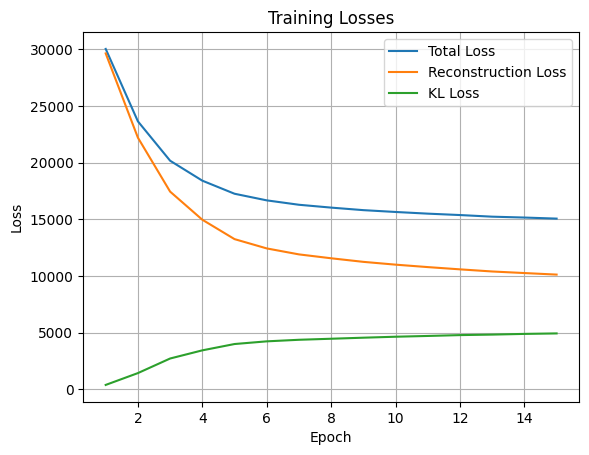

Training: 100%|██████████| 15/15 [01:51<00:00,  7.45s/it]


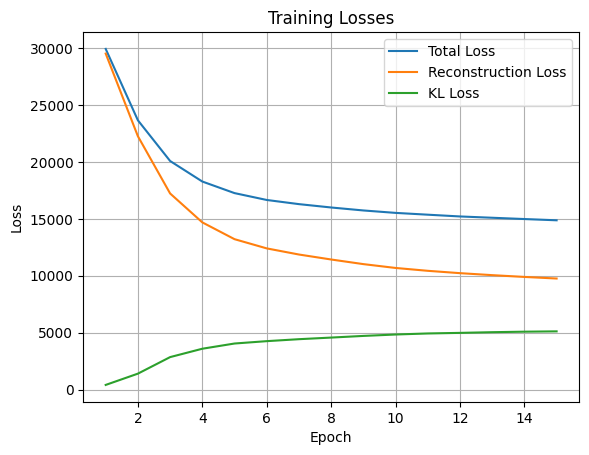

Training: 100%|██████████| 15/15 [01:49<00:00,  7.29s/it]


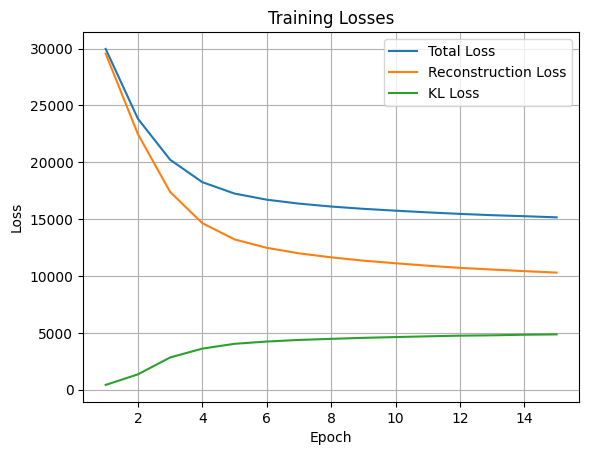

In [ ]:
# Train with L = 1, 10, 100 and plot KL curves
# YOUR CODE HERE
for L in [1, 10, 100]:
    model     = VAE().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train(model, optimizer, vae_loss_mc, train_loader)

---
## Part 3  $\beta$-VAE and Posterior Collapse

We introduce a scalar $\beta \geq 0$ weighting the KL term:

$$\mathcal{L}_\beta = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - \beta \cdot D_{\mathrm{KL}}(q_\phi(z|x) \| p(z))$$

The standard VAE is $\beta = 1$. Higgins et al. (2017) showed $\beta > 1$ encourages disentangled representations at the cost of reconstruction quality.

### Q3.1  Training (5 pts)

Modify your training loop to accept `beta`. Train three models with $\beta \in \{0.1, 1.0, 10.0\}$ for `EPOCHS` epochs. Show plots of the reconstruction and KL loss curves for all three settings.

In [ ]:
betas    = [0.1, 1.0, 10.0]
histories = {}

for beta in betas:
    # YOUR CODE HERE
    pass

# Plot reconstruction and KL loss curves for all three β values
# YOUR PLOT HERE

### Q3.2 — Posterior Collapse Analysis (15 pts)

Posterior collapse occurs when the encoder ignores the input and maps everything to the prior: $q_\phi(z|x) \approx p(z)$ regardless of $x$.

1. For each trained model, use `compute_active_dims` below to compute the per-dimension variance of the encoder means across the test set.
2. For each $\beta$, show a plot of the per-dimension variance across all 20 latent dimensions.
3. What happens to the latent dimensions under $\beta = 10.0$? Provide a explanation why does a large $\beta$ incentivize the encoder to ignore the input? Why does the decoder then receive no useful signal from those dimensions?

In [ ]:
def compute_active_dims(model, loader, device=DEVICE):
    """
    Returns: (z_dim,) tensor — per-dimension variance of encoder means
    across the test set.
    """
    model.eval()
    all_mu = []
    with torch.no_grad():
        for x, _ in loader:
            mu, _ = model.encoder(x.to(device))
            all_mu.append(mu.cpu())
    all_mu = torch.cat(all_mu, dim=0)   # (N_test, z_dim)
    return all_mu.var(dim=0)            # (z_dim,)

# Compute and plot active dimensions for each β
# YOUR CODE HERE

---
## Part 4  Geometry of the Latent Space

### Q4.1  Linear Interpolation (15 pts)

A well-trained VAE should produce a smooth, connected latent space: nearby points in $\mathbb{R}^d$ should decode to semantically similar images.

Using your $\beta = 1.0$ model:

1. Pick one test image of digit "2" and one of digit "7". Pass each through the encoder and record the **mean vectors** $\mu_A$ and $\mu_B$ (use the mean, not a sample).
2. Generate 10 interpolated latent vectors: $z_t = (1-t)\,\mu_A + t\,\mu_B,\quad t \in \{0.0,\,0.1,\,\ldots,\,1.0\}$
3. Decode each $z_t$ and display the resulting images.
4. Do you observe a smooth semantic transition? Describe what the intermediate images look like. Why does the KL regularization term play a direct role in enabling this, while a standard Autoencoder (no KL term) would not guarantee it?

In [ ]:
# YOUR CODE HERE

### Q4.2 — 2-D Latent Space Visualization *(Bonus, 10 pts)*

Retrain a VAE with `Z_DIM = 2`. Encode the full test set, collect all $\mu$ vectors, and plot them colored by digit class. Describe the structure: are digit classes separated? Do visually similar digits cluster near each other?

In [ ]:
# YOUR CODE HERE

---
## References

- Kingma, D. P. & Welling, M. (2013). *Auto-Encoding Variational Bayes.* ICLR 2014. arXiv:1312.6114  
- Higgins, I. et al. (2017). *β-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework.* ICLR 2017.  
- Lucas, J. et al. (2019). *Don't Blame the ELBO! A Linear VAE Perspective on Posterior Collapse.* NeurIPS 2019.